# Building custom attention matrices: "attention is FC + noise"

The hypothesis, as a rule over the attention matrix's block structure.

The `[4240, 4240]` attention matrix is a `10 x 10` grid of `424 x 424` submatrices
(`num_patches x num_patches` grid of `num_regions x num_regions` blocks), because BrainLM's
token order is region-major: token `i` = `region * num_patches + time_patch`.

1. Every block on the **grid diagonal** (source and target share a time patch) is the subject's
   **FC matrix**.
2. Optionally, blocks **displaced from the grid diagonal** by a fixed number of blocks also hold
   FC. We build the matrices both ways and keep both, so the zero-shot notebook can test whether
   these extra blocks help.
3. Every other block is **random noise**, with a small standard deviation so FC stands out.
4. Rows are normalized, giving a valid non-negative attention matrix.
5. Depth is a diffusive process running out: layer 0 is the noisiest, and the last layer has no
   noise at all.

This notebook builds them, plots them against the model's real attention, and saves what the
zero-shot notebook needs. This is the **13M** checkpoint: 424 regions x 10 patches x 20 TR =
200 TR, and the FC placed in each block is computed on exactly those 200 TR.

In [1]:
import os
import sys
import json

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_num_threads(MAX_CPU_THREADS)
sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data
from custom_attention import (compute_fc, token_region_patch, fc_block_mask, noise_schedule,
                              build_custom_attention, region_lag_profile)

# run_model imports visualize_attention, which sets the Agg backend for headless runs.
get_ipython().run_line_magic("matplotlib", "inline")

In [2]:
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO, SUBFOLDER = "vandijklab/brainlm", "old_13M"

WINDOW_SIZE = 200
DEMO_SUBJECT = 0          # subject shown in every plot below
N_SUBJECTS = 25           # subjects whose FC gets saved for the zero-shot notebook
RANDOM_SEED = 0
NOISE_START_FRACTION = 2 / 3   # layer-0 noise std, as a fraction of mean|FC|

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs/custom_attention"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()
spatial_coords = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
num_layers = config.num_hidden_layers

print(f"{num_regions} regions x {num_patches} patches x {patch_size} TR = {seq_len} tokens, "
      f"{WINDOW_SIZE} TR window, {num_layers} layers")

/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


424 regions x 10 patches x 20 TR = 4240 tokens, 200 TR window, 4 layers


In [4]:
def load_subject(subject_index):
    """Subject id, the model's input tensor for window 0, and that window's raw time series."""
    with h5py.File(INPUT_H5, "r") as f:
        sub_id = f["subject_ids"][subject_index].decode("utf-8")
        raw = f["parcel_ts"][subject_index, :, :]
    x = preprocess_subject_data(raw, num_windows=3, window_size=WINDOW_SIZE)[0:1]
    return sub_id, x.to(device), raw[:WINDOW_SIZE, :].T


def real_attention_per_layer(x):
    """Every layer's real attention, unmasked, heads averaged, CLS dropped."""
    identity_noise = (torch.arange(seq_len, dtype=torch.float32) / seq_len).unsqueeze(0).to(device)
    original_mask_ratio = model.config.mask_ratio
    model.config.mask_ratio = 0.0
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=identity_noise)
    finally:
        model.config.mask_ratio = original_mask_ratio
    return [a[0].mean(dim=0).cpu().numpy()[1:, 1:] for a in out.attentions]


sub_id, x_demo, window_demo = load_subject(DEMO_SUBJECT)
fc_demo = compute_fc(window_demo)
real_attn = real_attention_per_layer(x_demo)
print(f"{sub_id}: FC {fc_demo.shape}, real attention {real_attn[0].shape} per layer")

Sub_0000: FC (424, 424), real attention (4240, 4240) per layer


## Choosing the displacement of the off-diagonal FC blocks

The displaced bands visible in the real attention matrix are a **region-lag** feature: in
region-major order a fixed region-lag `L` sits at the constant token offset `L * num_patches`,
so it shows up as one continuous band parallel to the diagonal. The lag with the strongest mean
`|FC|` is the homotopic (cross-hemisphere) separation. We convert that token offset into the
nearest whole number of `424`-wide blocks and use it as the block displacement.

In [5]:
lags = np.arange(1, num_regions)
mean_abs_per_lag = np.array([np.abs(np.diag(fc_demo, k)).mean() for k in lags])
homotopic_lag = int(lags[np.argmax(mean_abs_per_lag)])
homotopic_offset = homotopic_lag * num_patches
BLOCK_OFFSET = max(1, round(homotopic_offset / num_regions))

print(f"homotopic region-lag {homotopic_lag}: mean |FC| = {mean_abs_per_lag.max():.3f} "
      f"vs {np.median(mean_abs_per_lag):.3f} median across lags")
print(f"-> token offset {homotopic_offset} -> block displacement {BLOCK_OFFSET}")

homotopic region-lag 180: mean |FC| = 0.342 vs 0.119 median across lags
-> token offset 1800 -> block displacement 4


In [6]:
regions, patches = token_region_patch(num_regions, num_patches)
mean_abs_fc = float(np.abs(fc_demo).mean())
noise_scales = noise_schedule(mean_abs_fc, num_layers, NOISE_START_FRACTION)

# The two versions we build and compare throughout.
VARIANTS = {"diagonal blocks": None, "diagonal + displaced blocks": BLOCK_OFFSET}


def build_all_layers(fc_matrix, block_offset, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    return [build_custom_attention(fc_matrix, regions, patches, noise_scales[layer], rng, block_offset)
            for layer in range(num_layers)]


custom_attn = {name: build_all_layers(fc_demo, offset) for name, offset in VARIANTS.items()}

print(f"mean|FC| = {mean_abs_fc:.3f}, noise std per layer: {np.round(noise_scales, 4)}")
for name, offset in VARIANTS.items():
    print(f"{name:28s}: FC fills {100 * fc_block_mask(patches, offset).mean():.0f}% of the matrix")

mean|FC| = 0.127, noise std per layer: [0.0844 0.0563 0.0281 0.    ]
diagonal blocks             : FC fills 10% of the matrix
diagonal + displaced blocks : FC fills 22% of the matrix


## Which blocks hold FC

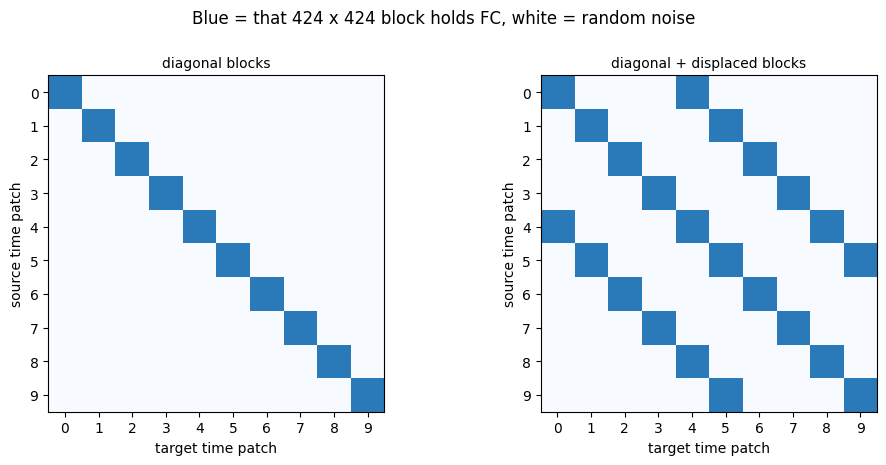

In [7]:
small_patches = np.arange(num_patches)   # one cell per block of the 10 x 10 grid

fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 4.6))
for ax, (name, offset) in zip(axes, VARIANTS.items()):
    ax.imshow(fc_block_mask(small_patches, offset), cmap="Blues", vmin=0, vmax=1.4)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("target time patch")
    ax.set_ylabel("source time patch")
    ax.set_xticks(range(num_patches))
    ax.set_yticks(range(num_patches))
fig.suptitle("Blue = that 424 x 424 block holds FC, white = random noise", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "custom_attention_block_layout.png"), dpi=130, bbox_inches="tight")
plt.show()

## Real attention vs. our reconstruction

Top row is the model's **real attention, untouched, in its native token order** -- the ground
truth we are trying to reproduce.

The reconstructions below are shown in **patch-major order**, the ordering their rule is written
in: each same-time-patch block is a contiguous `424 x 424` square, so the FC blocks sit on the
grid diagonal and, for the second variant, on two more block-diagonals displaced from it. This
reordering is display-only -- the rule picks out the same token pairs either way, and the matrix
handed to the model is always indexed in the model's native token order.

The reconstructions are scaled to the median of their own FC cells, so FC reads bright against
the noise floor; real attention keeps a 1st/99th percentile scale.

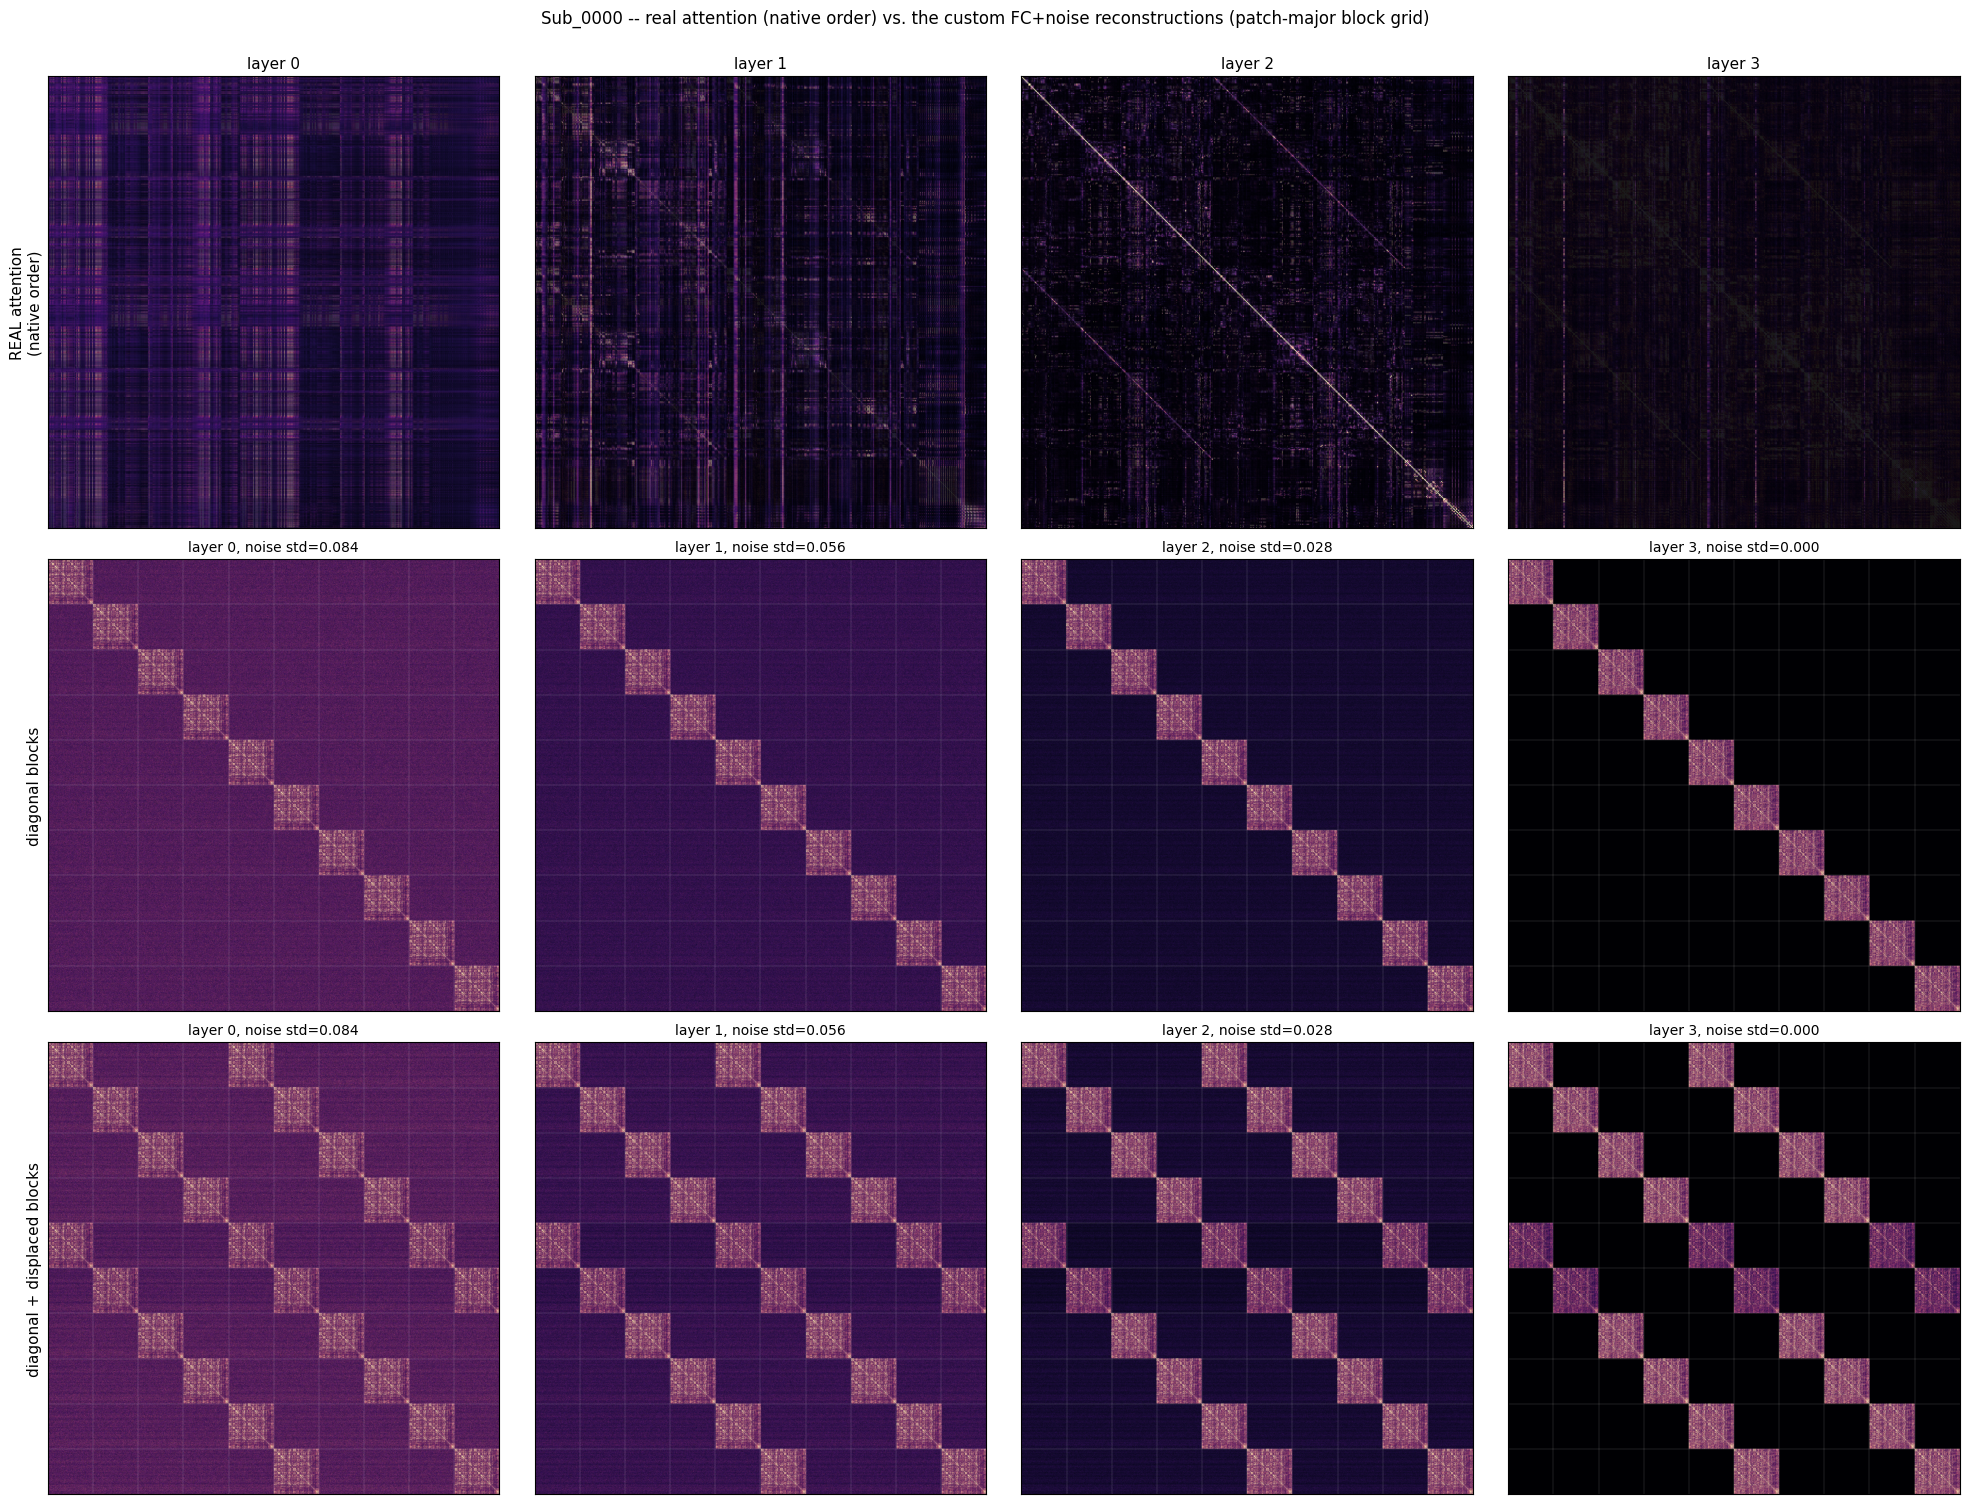

In [8]:
# Patch-major ordering: sort tokens by time patch first, region second, so each same-time-patch
# block becomes a contiguous 424 x 424 square. Display only -- see the note above.
patch_major = np.lexsort((regions, patches))
block_edges = np.arange(1, num_patches) * num_regions

rows = [("REAL attention\n(native order)", real_attn, None)]
rows += [(name, custom_attn[name], fc_block_mask(patches, offset)) for name, offset in VARIANTS.items()]

fig, axes = plt.subplots(len(rows), num_layers, figsize=(5 * num_layers, 5 * len(rows)))
for row, (label, mats, fc_mask) in enumerate(rows):
    for layer in range(num_layers):
        ax = axes[row, layer]
        matrix = mats[layer]
        if fc_mask is None:
            ax.imshow(matrix, cmap="magma", vmin=np.percentile(matrix, 1), vmax=np.percentile(matrix, 99))
            ax.set_title(f"layer {layer}", fontsize=11)
        else:
            # Scale to the FC cells themselves: they are 10-22% of the matrix, so any global high
            # percentile would sit inside the FC distribution and render it dim. The 90th
            # percentile clips only the brightest 10%, keeping FC's texture visible inside blocks.
            shown = matrix[np.ix_(patch_major, patch_major)]
            ax.imshow(shown, cmap="magma", vmin=0, vmax=float(np.percentile(matrix[fc_mask], 90)))
            ax.set_title(f"layer {layer}, noise std={noise_scales[layer]:.3f}", fontsize=10)
            for edge in block_edges:
                ax.axhline(edge - 0.5, color="white", linewidth=0.3, alpha=0.3)
                ax.axvline(edge - 0.5, color="white", linewidth=0.3, alpha=0.3)
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(label, fontsize=11)

fig.suptitle(f"{sub_id} -- real attention (native order) vs. the custom FC+noise reconstructions "
             "(patch-major block grid)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_real_vs_custom_attention.png"), dpi=130, bbox_inches="tight")
plt.show()

## Where the structure sits, by region-lag

Mean `|value|` along the diagonal at token offset `L * num_patches`, for each region-lag `L`.
The peak at lag 0 is self-attention; the isolated peak further out is the homotopic band. This
is the sharpest way to check whether a reconstruction puts its mass where real attention does.

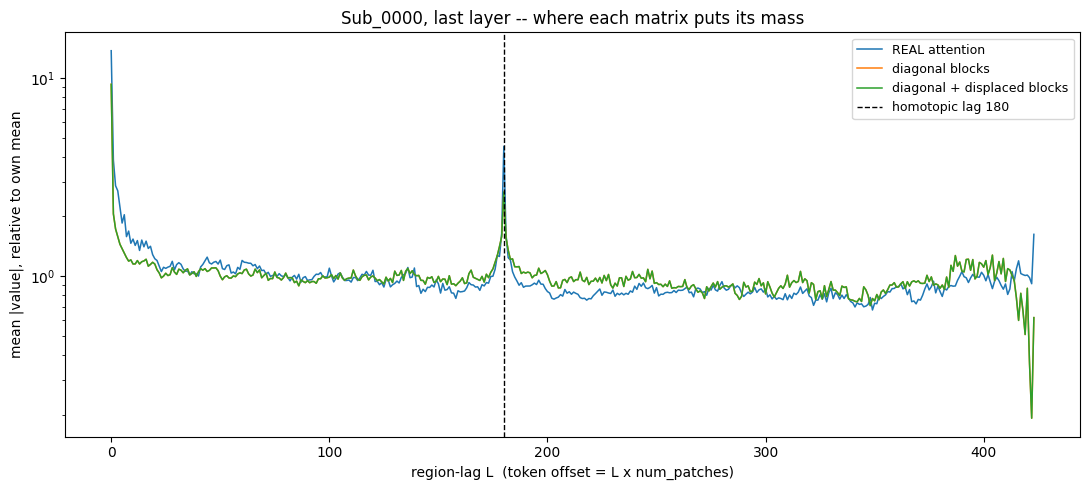

In [9]:
max_lag = num_regions
profiles = {"REAL attention": region_lag_profile(real_attn[-1], num_patches, max_lag)}
for name in VARIANTS:
    profiles[name] = region_lag_profile(custom_attn[name][-1], num_patches, max_lag)

fig, ax = plt.subplots(figsize=(11, 5))
for name, profile in profiles.items():
    ax.semilogy(np.arange(max_lag), profile / profile.mean(), linewidth=1.1, label=name)
ax.axvline(homotopic_lag, color="black", linestyle="--", linewidth=1, label=f"homotopic lag {homotopic_lag}")
ax.set_xlabel("region-lag L  (token offset = L x num_patches)")
ax.set_ylabel("mean |value|, relative to own mean")
ax.set_title(f"{sub_id}, last layer -- where each matrix puts its mass")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_region_lag_profiles.png"), dpi=130, bbox_inches="tight")
plt.show()

## How closely does each reconstruction match real attention?

The reconstructions are built only from FC and independent noise -- they never read the model's
attention -- so any correlation comes from the FC placement being right.

diagonal blocks             : layer 0 r=0.006  layer 1 r=0.333  layer 2 r=0.111  layer 3 r=0.619


diagonal + displaced blocks : layer 0 r=0.007  layer 1 r=0.246  layer 2 r=0.141  layer 3 r=0.384


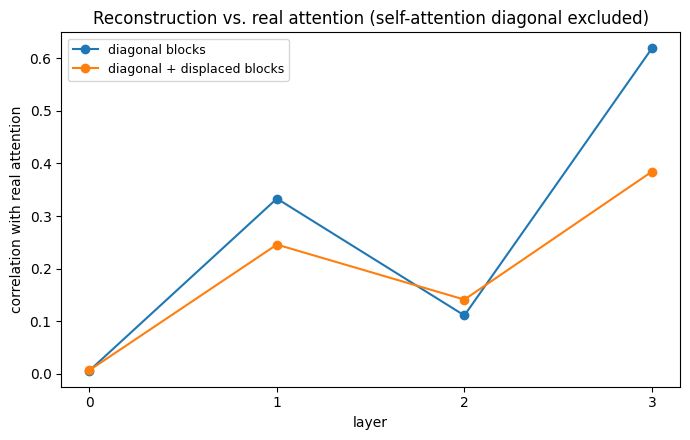

In [10]:
offdiag = ~np.eye(seq_len, dtype=bool)   # excludes the trivial self-attention diagonal

fig, ax = plt.subplots(figsize=(7, 4.5))
for name in VARIANTS:
    corr = [np.corrcoef(real_attn[layer][offdiag], custom_attn[name][layer][offdiag])[0, 1]
            for layer in range(num_layers)]
    ax.plot(range(num_layers), corr, marker="o", label=name)
    print(f"{name:28s}: " + "  ".join(f"layer {l} r={c:.3f}" for l, c in enumerate(corr)))

ax.set_xlabel("layer")
ax.set_ylabel("correlation with real attention")
ax.set_title("Reconstruction vs. real attention (self-attention diagonal excluded)")
ax.set_xticks(range(num_layers))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_reconstruction_correlation.png"), dpi=130, bbox_inches="tight")
plt.show()

## Save what the zero-shot notebook needs

The full matrices are ~72 MB each, so we save the FC matrix per subject plus the construction
parameters instead. Together they determine the custom attention exactly, and the zero-shot
notebook rebuilds it with the same shared code -- it also has to, since the matrices it needs
cover only the tokens left after masking.

In [11]:
fc_by_subject = {}
for subject_index in range(N_SUBJECTS):
    sid, _, window = load_subject(subject_index)
    if np.isnan(window).any():
        print(f"{sid}: skipped (NaNs in the first {WINDOW_SIZE} TRs)")
        continue
    fc_by_subject[sid] = compute_fc(window).astype(np.float32)

np.savez_compressed(os.path.join(OUTPUTS_DIR, "fc_matrices.npz"), **fc_by_subject)

params = {"window_size": WINDOW_SIZE, "num_regions": num_regions, "num_patches": num_patches,
          "num_layers": num_layers, "random_seed": RANDOM_SEED,
          "noise_start_fraction": NOISE_START_FRACTION, "block_offset": BLOCK_OFFSET,
          "homotopic_lag": homotopic_lag, "subjects": list(fc_by_subject)}
with open(os.path.join(OUTPUTS_DIR, "params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"saved FC for {len(fc_by_subject)} subjects + params -> {OUTPUTS_DIR}/")
print(json.dumps({k: v for k, v in params.items() if k != "subjects"}, indent=2))

saved FC for 25 subjects + params -> outputs/custom_attention/
{
  "window_size": 200,
  "num_regions": 424,
  "num_patches": 10,
  "num_layers": 4,
  "random_seed": 0,
  "noise_start_fraction": 0.6666666666666666,
  "block_offset": 4,
  "homotopic_lag": 180
}
